<a href="https://colab.research.google.com/github/Yash-k10/pattern_recognition/blob/main/Practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural          

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1



Decision Tree Results
Accuracy: 0.7642276422764228

Confusion Matrix
[[23 15]
 [14 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.61      0.61        38
           1       0.83      0.84      0.83        85

    accuracy                           0.76       123
   macro avg       0.72      0.72      0.72       123
weighted avg       0.76      0.76      0.76       123


Feature Importance
              Feature  Importance
9      Credit_History    0.261446
7          LoanAmount    0.208105
5     ApplicantIncome    0.185021
6   CoapplicantIncome    0.133345
10      Property_Area    0.054374
2          Dependents    0.038936
8    Loan_Amount_Term    0.035406
3           Education    0.026743
1             Married    0.023589
0              Gender    0.022154
4       Self_Employed    0.010882


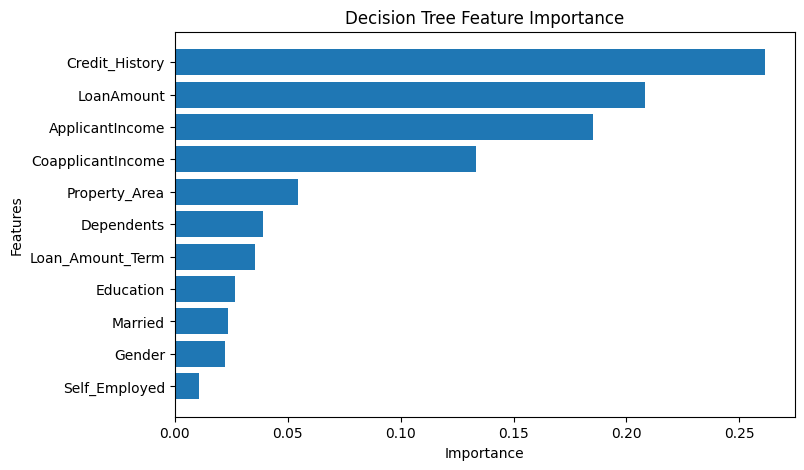


KNN Results
Accuracy: 0.8455284552845529

Confusion Matrix
[[22 16]
 [ 3 82]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        38
           1       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123


Model Comparison
Decision Tree Accuracy : 0.7642
KNN Accuracy           : 0.8455

KNN performed better.


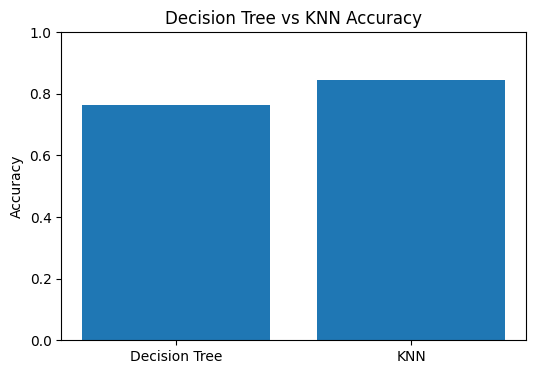

In [3]:
# ==========================================
# Loan Approval Prediction using
# Decision Tree & KNN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("trainX.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# Drop Loan_ID
# ==========================================

df.drop("Loan_ID", axis=1, inplace=True)

# ==========================================
# Fill Missing Values
# ==========================================

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ==========================================
# Encode Categorical Columns
# ==========================================

label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset")
display(df.head())

# ==========================================
# Features and Target
# ==========================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# Decision Tree
# ==========================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("\n==============================")
print("Decision Tree Results")
print("==============================")

print("Accuracy:", dt_acc)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# ==========================================
# Standardize Data for KNN
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# KNN
# ==========================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)

print("\n==============================")
print("KNN Results")
print("==============================")

print("Accuracy:", knn_acc)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

# ==========================================
# Accuracy Comparison
# ==========================================

print("\n==============================")
print("Model Comparison")
print("==============================")

print(f"Decision Tree Accuracy : {dt_acc:.4f}")
print(f"KNN Accuracy           : {knn_acc:.4f}")

if dt_acc > knn_acc:
    print("\nDecision Tree performed better.")
elif knn_acc > dt_acc:
    print("\nKNN performed better.")
else:
    print("\nBoth models performed equally.")

# ==========================================
# Accuracy Comparison Graph
# ==========================================

models = ["Decision Tree", "KNN"]
accuracy = [dt_acc, knn_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Decision Tree vs KNN Accuracy")
plt.show()